Saving archive.zip to archive.zip
Columns in dataset: Index(['Month', '#Passengers'], dtype='object')

First 5 rows:
            Value
Date             
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121

Missing values:
Value    0
dtype: int64


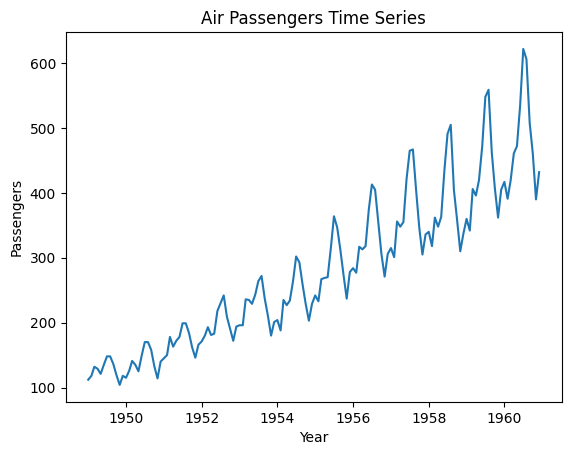

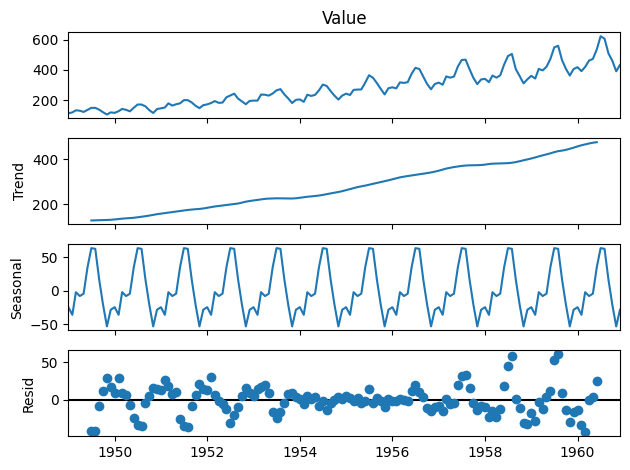

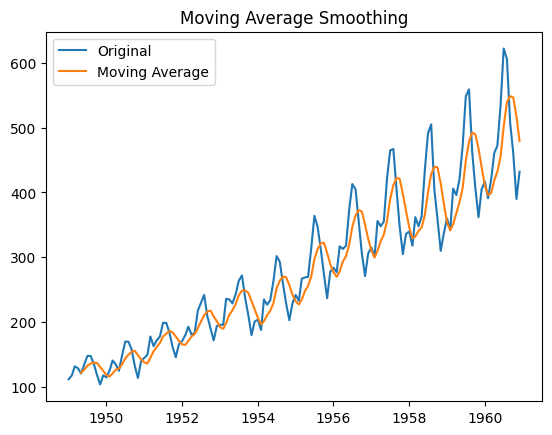


--- Interpretation ---
1. Trend: Passenger numbers increase over time.
2. Seasonality: Clear yearly repeating pattern.
3. Residual: Random variations after removing trend & seasonality.


In [1]:
# =========================
# STEP 1: Install library
# =========================
!pip install statsmodels

# =========================
# STEP 2: Import libraries
# =========================
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# =========================
# STEP 3: Upload dataset (Kaggle CSV)
# =========================
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# =========================
# STEP 4: Load dataset
# =========================
df = pd.read_csv(file_name)

print("Columns in dataset:", df.columns)

# =========================
# STEP 5: Handle column names
# =========================
# Common Kaggle names: 'Month' & 'Passengers'
df.columns = ['Date', 'Value']   # rename for simplicity

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set index
df.set_index('Date', inplace=True)

# Sort data
df = df.sort_index()

print("\nFirst 5 rows:")
print(df.head())

# =========================
# STEP 6: Check missing values
# =========================
print("\nMissing values:")
print(df.isnull().sum())

# =========================
# STEP 7: Plot time series
# =========================
plt.figure()
plt.plot(df['Value'])
plt.title("Air Passengers Time Series")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

# =========================
# STEP 8: Decomposition
# =========================
decomposition = seasonal_decompose(df['Value'], model='additive', period=12)

decomposition.plot()
plt.show()

# =========================
# STEP 9: Moving Average
# =========================
df['Moving_Avg'] = df['Value'].rolling(window=5).mean()

plt.figure()
plt.plot(df['Value'], label='Original')
plt.plot(df['Moving_Avg'], label='Moving Average')
plt.title("Moving Average Smoothing")
plt.legend()
plt.show()

# =========================
# STEP 10: Interpretation
# =========================
print("\n--- Interpretation ---")
print("1. Trend: Passenger numbers increase over time.")
print("2. Seasonality: Clear yearly repeating pattern.")
print("3. Residual: Random variations after removing trend & seasonality.")